# 🏨 «Прогнозирование отмен бронирований в сети отелей UrbanStay: ML‑подход к повышению загрузки»

Автор: Якунин Михаил

Дата: "__" _______ 2026 г.

***По этой ссылке можно посмотреть проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint17_Booking_Cancellation_Predict.git***

## Цель проекта

## Задача проекта

## Описание данных

## Содержание <a id="content"></a>

* [1. Подготовка данных](#1)
  * [1.1. Подготовка среды и библиотек](#1_1)
  * [1.2. Загрузка данных](#1_2)
  * [1.3. Исследовательский анализ данных и предобработка](#1_3)
* [2. ](#2)
  * [2.1. ](#2_1)
* [3. ](#3)
* [4. ](#4)
  * [4.1. ](#4_1)
* [5. ](#5)
  * [5.1. ](#5_1)
* [6. ](#6)
  * [6.1. ](#6_1)
* [7. ](#7)
* [8. ](#8)



## [Этап 1: Подготовка данных <a id=1></a>](#content)

### [1.1 Подготовка среды и библиотек <a id=1_1></a>](#content)

In [1]:
# Установка необходимых библиотек
# !pip install -r requirements.txt

In [2]:
# Стандартные библиотеки


# Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sqlalchemy import create_engine

d:\ProjectPython\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Устанавка константных параметров
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Параметры для подключения к данным PostgreSQL 
db_config = {'user': 'praktikum_student', 
             'pwd': 'Sdf4$2;d-d30pp', 
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': '6432', 
             'db': 'data-scientist-hotels' 
             } 

In [4]:
# Настройки Pandas для отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))
pd.set_option('display.memory_usage', True)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Отключает научную нотацию (экспоненциальную запись) на оси Y для всех графиков
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = [-99, 99]

# Подавляем INFO-сообщения Optuna, оставляем только предупреждения и ошибки 
optuna.logging.set_verbosity(optuna.logging.WARNING)

### [1.2 Загрузка данных <a id=1_2></a>](#content)

In [5]:
# Создаем подключение к БД
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

engine = create_engine(connection_string)

query_bookings = '''
SELECT *
FROM hotel_bookings
'''

query_reviews = '''
SELECT *
FROM hotel_reviews
'''

In [6]:
# Извлекаем даные из БД
df_bookings = pd.read_sql_query(query_bookings, con=engine)
df_reviews = pd.read_sql_query(query_reviews, con=engine)

# Создание словаря c датафреймами
dataframes = {
    'bookings': df_bookings,
    'reviews': df_reviews
}

In [7]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    """
    Выводит базовую сводную информацию о DataFrame: заголовок с именем таблицы,
    первые 5 строк, сводку типов и пропусков, а также описательную статистику.
    """
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [8]:
# Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6 700.00,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62 300.00,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46 900.00,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53 600.00,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.00,96,5,2,тип_питания_1,False,тип_1,1


<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  str    
 14  p

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,35341,30733,INN00327,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,35341,2445,2019-06-03,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,35341,3,офлайн_бронирование,12040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,35 341.00,NaN,NaN,NaN,12.48,45.73,1.00,1.00,2.00,3.00,300.00
child_count,35 341.00,NaN,NaN,NaN,0.36,0.59,0.00,0.00,0.00,1.00,2.00
returning_customer,35341,2,True,19928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,35 341.00,NaN,NaN,NaN,0.36,0.63,0.00,0.00,0.00,1.00,5.00
previous_no_shows,35 341.00,NaN,NaN,NaN,0.84,0.93,0.00,0.00,1.00,1.00,5.00
booking_status,35341,2,нет_отказа,25177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_value,35 341.00,NaN,NaN,NaN,61 634.06,42 837.59,0.00,33 500.00,53 600.00,80 400.00,417 221.20



Информация о таблице: reviews


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


<class 'pandas.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  str   
 1   booking_id   25177 non-null  str   
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  str   
dtypes: int64(1), object(1), str(3)
memory usage: 983.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,25177,13429,C4486,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_id,25177,21883,INN01741,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_date,25177,2514,2020-06-12,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stay_rating,25 177.00,NaN,NaN,NaN,3.40,0.54,2.00,3.00,3.00,4.00,5.00
review_text,25177,14153,Отличный отель! хорошие виды из окон.,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### [1.3 Исследовательский анализ данных и предобработка <a id=1_3></a>](#content)

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

#### Анализ дубликатов

In [9]:
# Приводим тип данных у признаков с датами
df_bookings['booking_date'] = pd.to_datetime(df_bookings['booking_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])

In [10]:
# Определянем функцию для выявления дубликатов в датасете
def duplicate_search(df_bookings, df_reviews):
    """
    Определяем все дубликаты строк и выводим их количество
    """
    # Определяем дубликаты
    bookings_dupl = df_bookings.duplicated(subset=['booking_id']).sum()
    reviews_dupl = df_reviews.duplicated(subset=['customer_id', 'booking_id', 'review_date']).sum()

    print("Дубликаты bookings:", bookings_dupl)
    print("Дубликаты reviews:", reviews_dupl)

In [11]:
# Выводим информацию об дубликатах
duplicate_search(df_bookings, df_reviews)

Дубликаты bookings: 4608
Дубликаты reviews: 130


In [12]:
# Удаляем дублирующие строки
df_bookings_drop_dupl = df_bookings.drop_duplicates(subset=['booking_id'])
df_reviews_drop_dupl = df_reviews.drop_duplicates(subset=['customer_id', 'booking_id', 'review_date'])

In [13]:
# Выводим информацию об дубликатах после очистки датасетов
duplicate_search(df_bookings_drop_dupl, df_reviews_drop_dupl)

Дубликаты bookings: 0
Дубликаты reviews: 0


#### Анализ числовых признаков

In [14]:
# Определяем числовые признаки
numeric_cols_booking = df_bookings_drop_dupl.select_dtypes(np.number).columns.to_list()
numeric_cols_reviews = df_reviews_drop_dupl.select_dtypes(np.number).columns.to_list()

In [15]:
# Функция вывода графика гистограммы
def print_histplot(df, column, ax):
    """
    Строит гистограмму распределения значений столбца с наложенной KDE-кривой,
    а также добавляет вертикальные линии для среднего и медианы с подписями.
    """
    # Гистограмма с KDE 
    sns.histplot(df[column], bins=100, kde=True, 
                color='steelblue', edgecolor='black', label='Гистограмма', ax=ax)

    # Получаем линию KDE и меняем её цвет
    for line in ax.lines:
        line.set_color('red')
        line.set_linewidth(2)
        line.set_label('KDE')

    # Добавляем вертикальные линии для среднего и медианы
    ax.axvline(df[column].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Среднее: {df[column].mean():,.2f} руб.')
    ax.axvline(df[column].median(), color='orange', linestyle='--', linewidth=2, 
            label=f'Медиана: {df[column].median():,.2f} руб.')

    # Подписываем оси и добавляем заголовок
    ax.set_ylabel('Плотность', fontsize=15)
    ax.set_title(f'Распределение\n для данных {column}', fontsize=20, fontweight='bold')
    ax.legend(fontsize=11)

In [16]:
# Функция вывода графика ящик с усами
def print_boxplot(df, column, ax):
    """
    Строит boxplot («ящик с усами») для заданного столбца DataFrame
    """
    # Boxplot (ящик с усами)
    ax.boxplot(df[column], vert=True, patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='navy', linewidth=2),
        capprops=dict(color='navy', linewidth=2),
        flierprops=dict(markerfacecolor='red', marker='o', markersize=6)
    )

    ax.set_title(f'Boxplot для {column}', fontsize=20, fontweight='bold')
    ax.set_ylabel('Значение', fontsize=15)
    ax.grid(True, alpha=0.3, axis='y')

    # Вычисляем ключевые статистики для аннотаций 
    q1 = df[column].quantile(0.25) 
    q3 = df[column].quantile(0.75) 
    median = df[column].median()

    # Размещаем текстовые аннотации
    ax.text(
        x=1.1, # Координата X (слева от бокса) 
        y=ax.get_ylim()[1] * 0.7, # Первая строка сверху 
        s=f'Q3: {q3}\nMedian: {median:.2f}\nQ1: {q1}\n',
        fontsize=15
    )

In [17]:
# Функция вывода графика распределения
def print_countplot(df, column, ax):
    """
    Строит countplot для заданного столбца DataFrame
    """
    if df[column].nunique() > 50:
        return

    # Распределение countplot
    sns.countplot(data=df, x=column, color='steelblue', ax=ax)

    ax.set_title(f'Распределение\n по количеству для {column}', fontsize=20, fontweight='bold')
    ax.set_ylabel('Количество', fontsize=15)

    # Добавляем значения над столбцами
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom'
        )

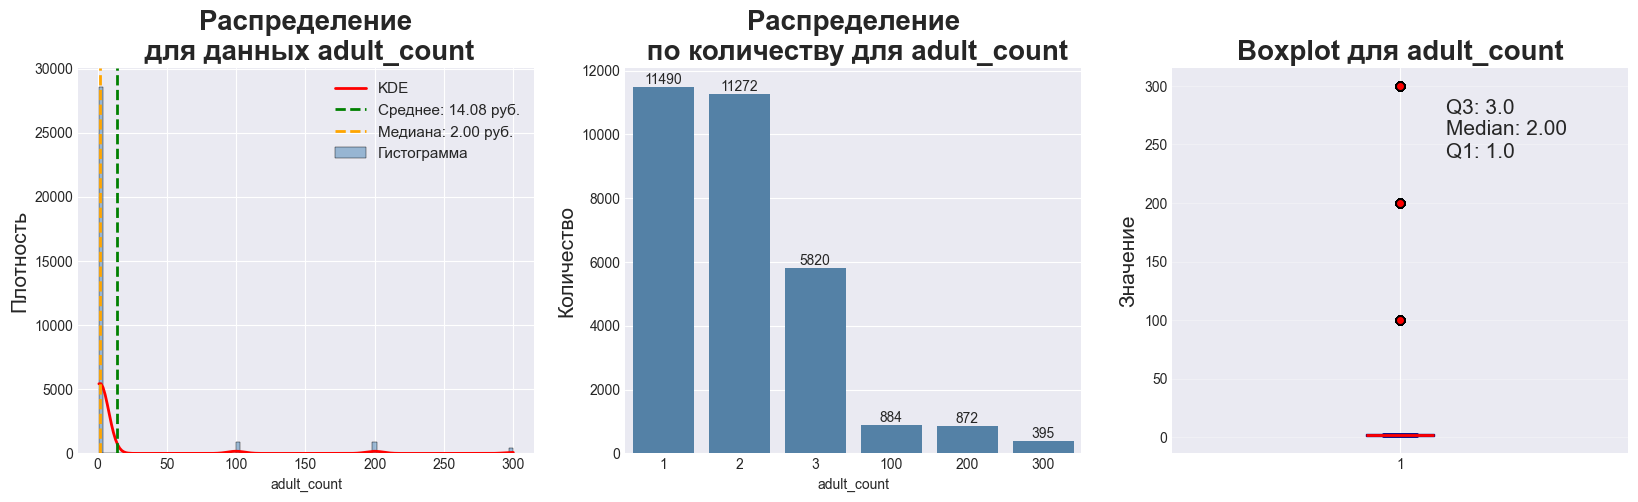

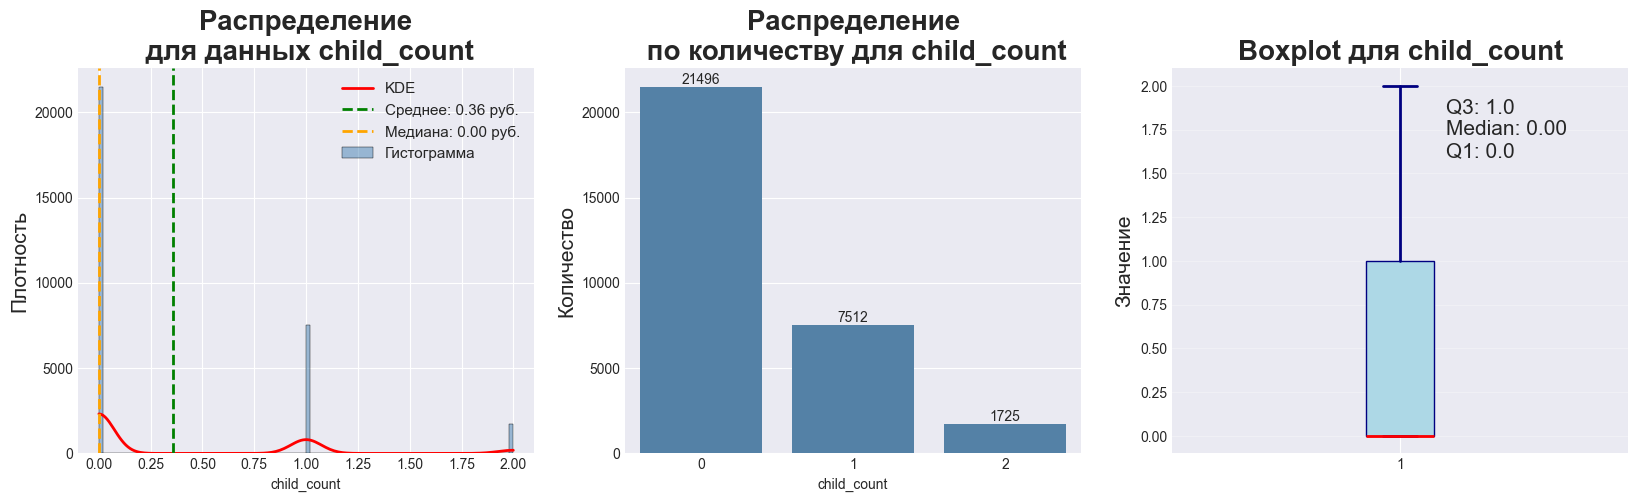

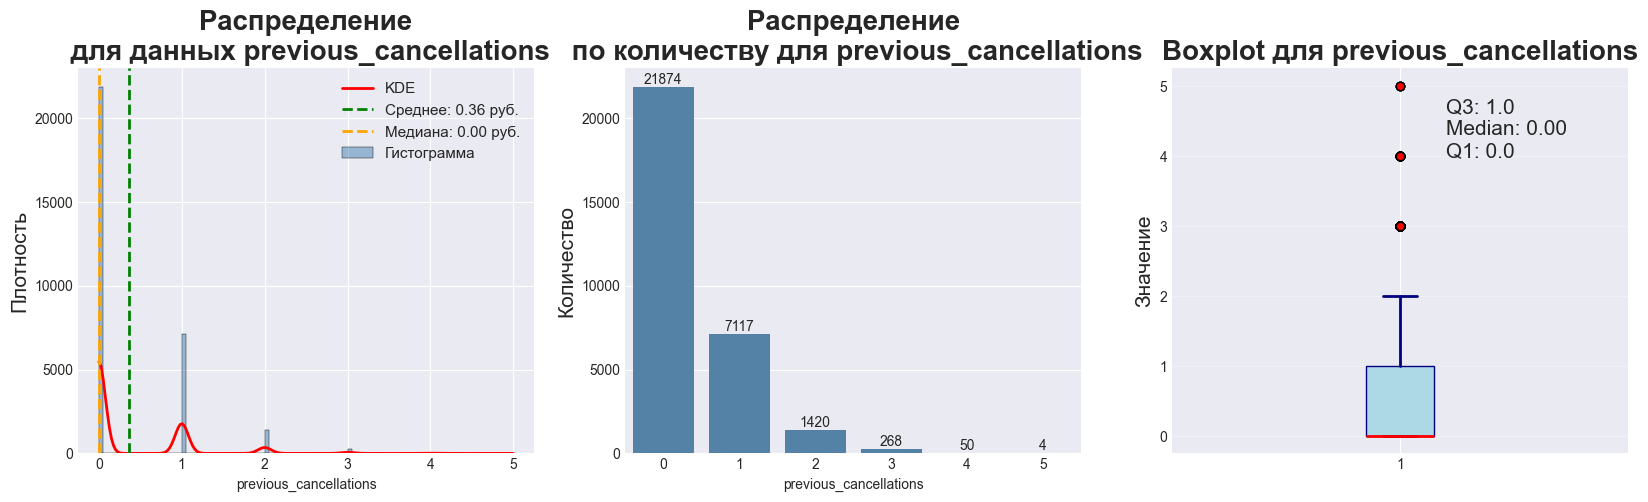

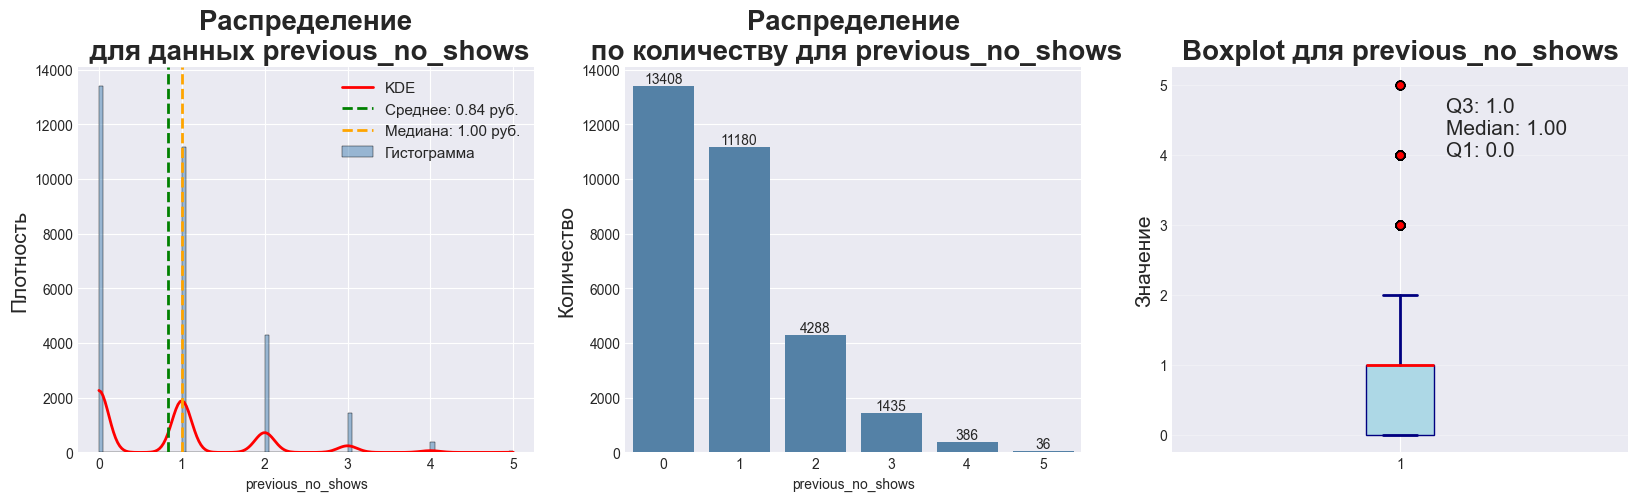

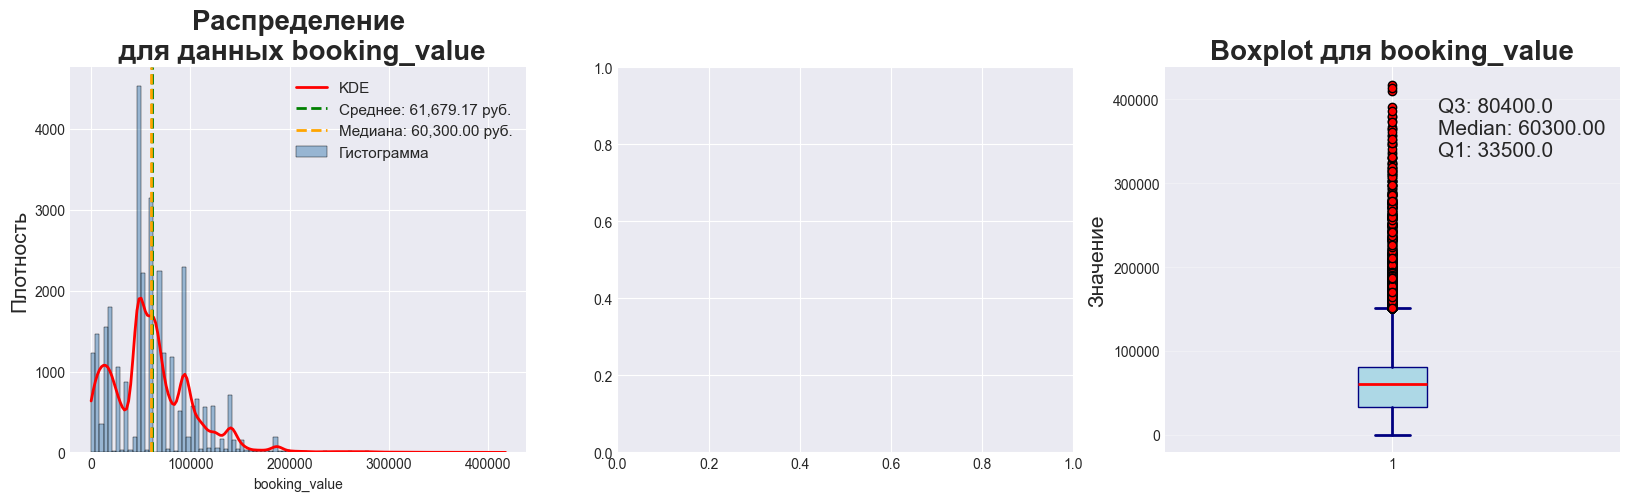

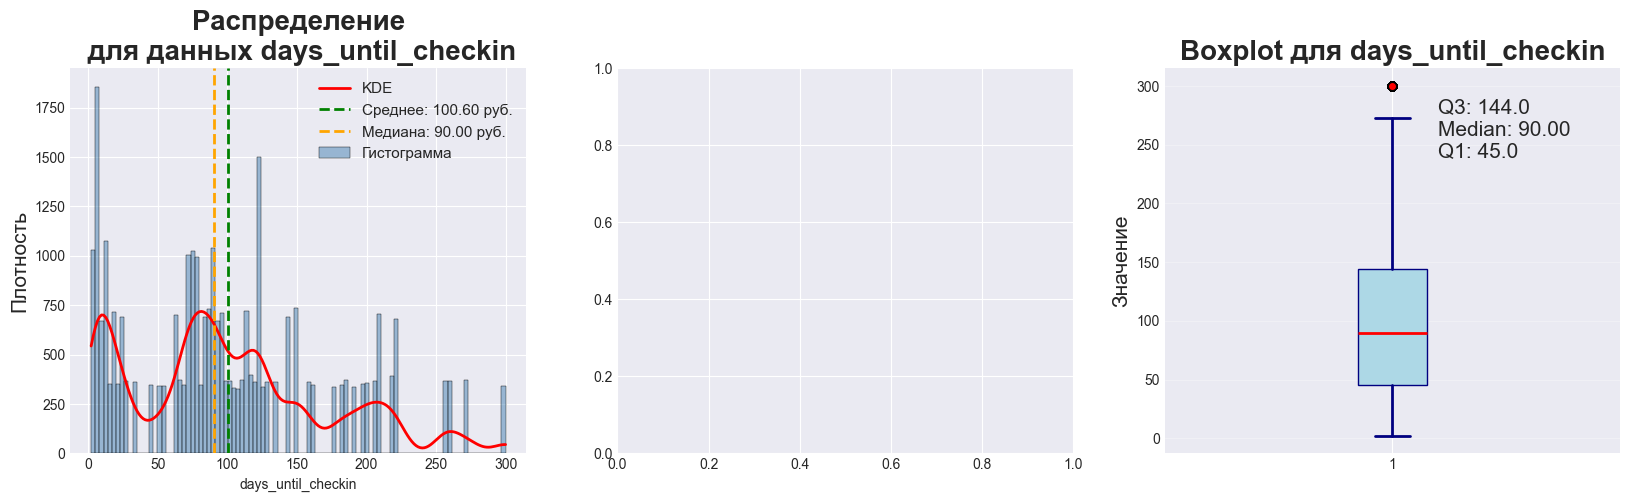

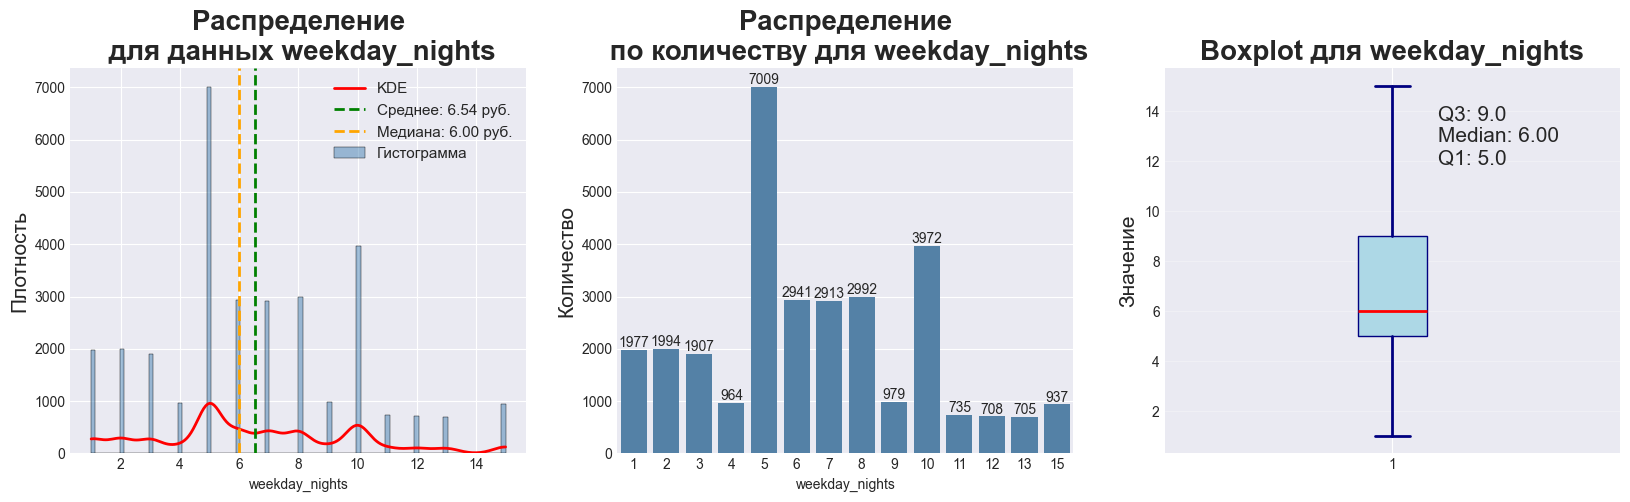

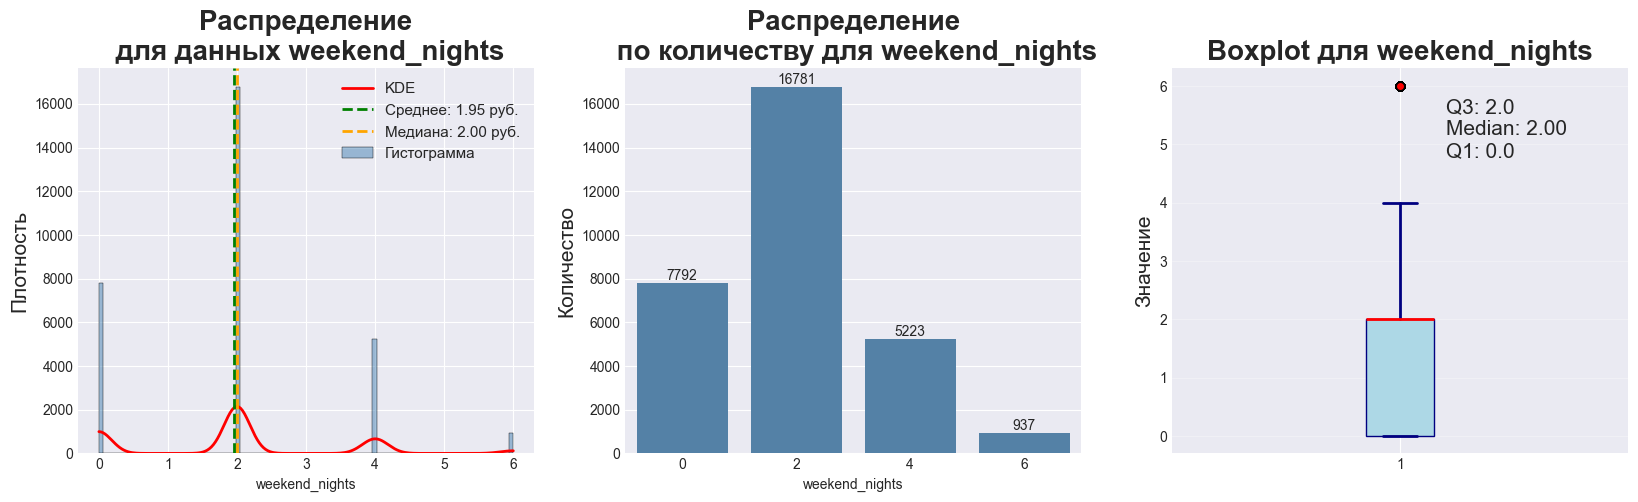

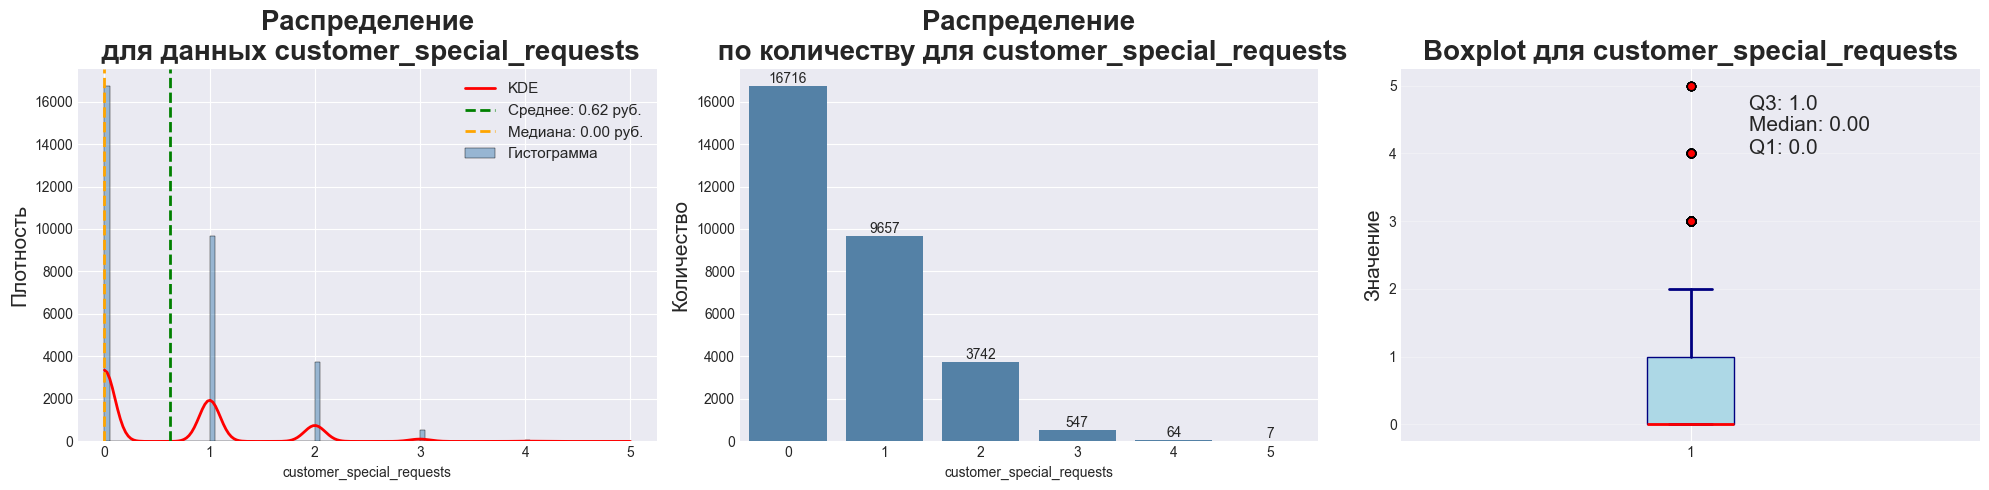

In [18]:
# Выводим графики для датасета df_bookings_drop_dupl
for col in numeric_cols_booking:
    _, axes = plt.subplots(1, 3, figsize=(20, 5))
    print_histplot(df_bookings_drop_dupl, col, axes[0])
    print_countplot(df_bookings_drop_dupl, col, axes[1])
    print_boxplot(df_bookings_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

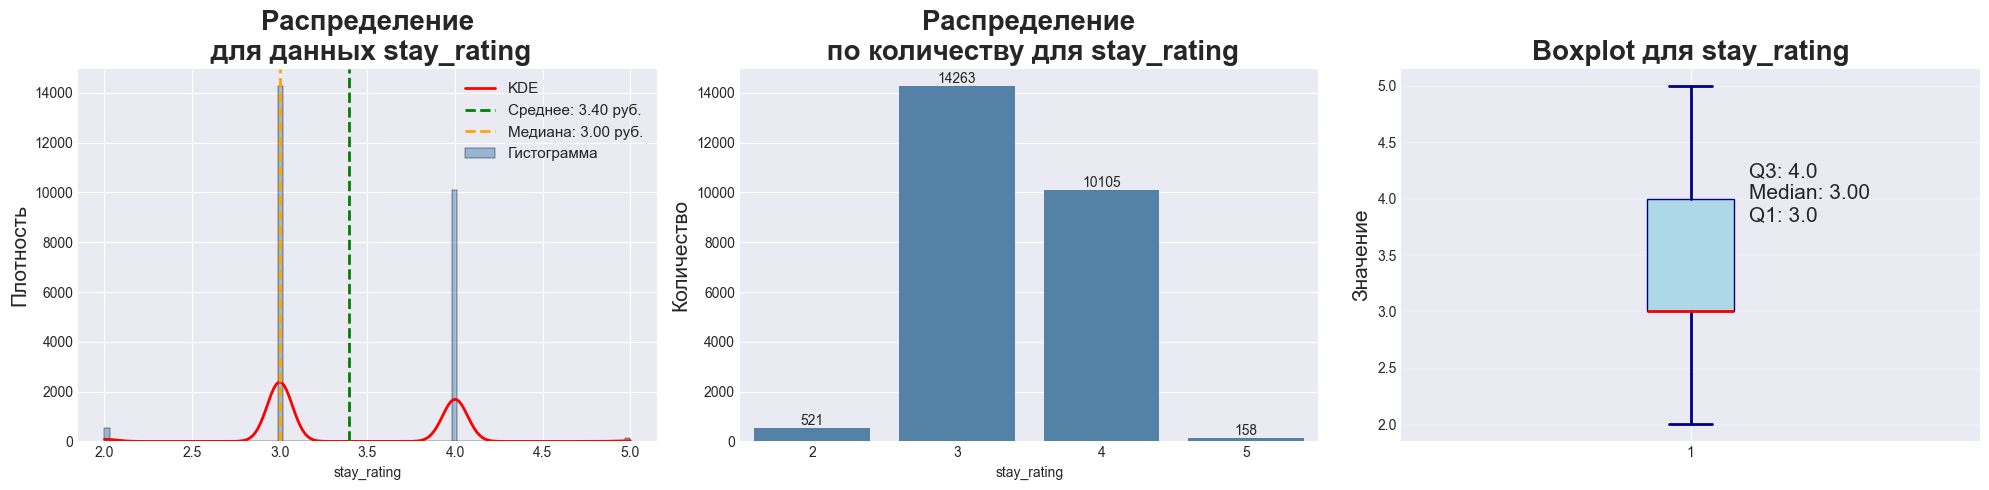

In [19]:
# Выводим графики для датасета df_reviews_drop_dupl
for col in numeric_cols_reviews:
    _, axes = plt.subplots(1, 3, figsize=(20, 5))
    print_histplot(df_reviews_drop_dupl, col, axes[0])
    print_countplot(df_reviews_drop_dupl, col, axes[1])
    print_boxplot(df_reviews_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

#### Анализ выбросов

In [20]:
# Функция рассчета выбросов
def mark_iqr_outliers(series): 
    q1 = series.quantile(0.25) 
    q3 = series.quantile(0.75) 
    iqr = q3 - q1 
    lower_bound = q1 - 1.5 * iqr 
    upper_bound = q3 + 1.5 * iqr 
    return ~series.between(lower_bound, upper_bound) 

In [21]:
# Определяем количество выбросов для датасета df_bookings
print('Анализ выбросов для датасета df_bookings\n')
for col in numeric_cols_booking: 
    outliers = mark_iqr_outliers(df_bookings_drop_dupl[col]) 
    print(f"Признак '{col}': найдено {outliers.sum()} выбросов по IQR")

Анализ выбросов для датасета df_bookings

Признак 'adult_count': найдено 2151 выбросов по IQR
Признак 'child_count': найдено 0 выбросов по IQR
Признак 'previous_cancellations': найдено 322 выбросов по IQR
Признак 'previous_no_shows': найдено 1857 выбросов по IQR
Признак 'booking_value': найдено 866 выбросов по IQR
Признак 'days_until_checkin': найдено 340 выбросов по IQR
Признак 'weekday_nights': найдено 0 выбросов по IQR
Признак 'weekend_nights': найдено 937 выбросов по IQR
Признак 'customer_special_requests': найдено 618 выбросов по IQR


In [22]:
# Определяем количество выбросов для датасета df_reviews
print('Анализ выбросов для датасета df_reviews\n')
for col in numeric_cols_reviews: 
    outliers = mark_iqr_outliers(df_reviews_drop_dupl[col]) 
    print(f"Признак '{col}': найдено {outliers.sum()} выбросов по IQR")

Анализ выбросов для датасета df_reviews

Признак 'stay_rating': найдено 0 выбросов по IQR


In [23]:
# Исправляем выбросы
mask = df_bookings_drop_dupl['adult_count'] >= 100
df_bookings_drop_dupl['adult_count'] = df_bookings_drop_dupl['adult_count'].where(~mask, df_bookings_drop_dupl['adult_count'] // 100)

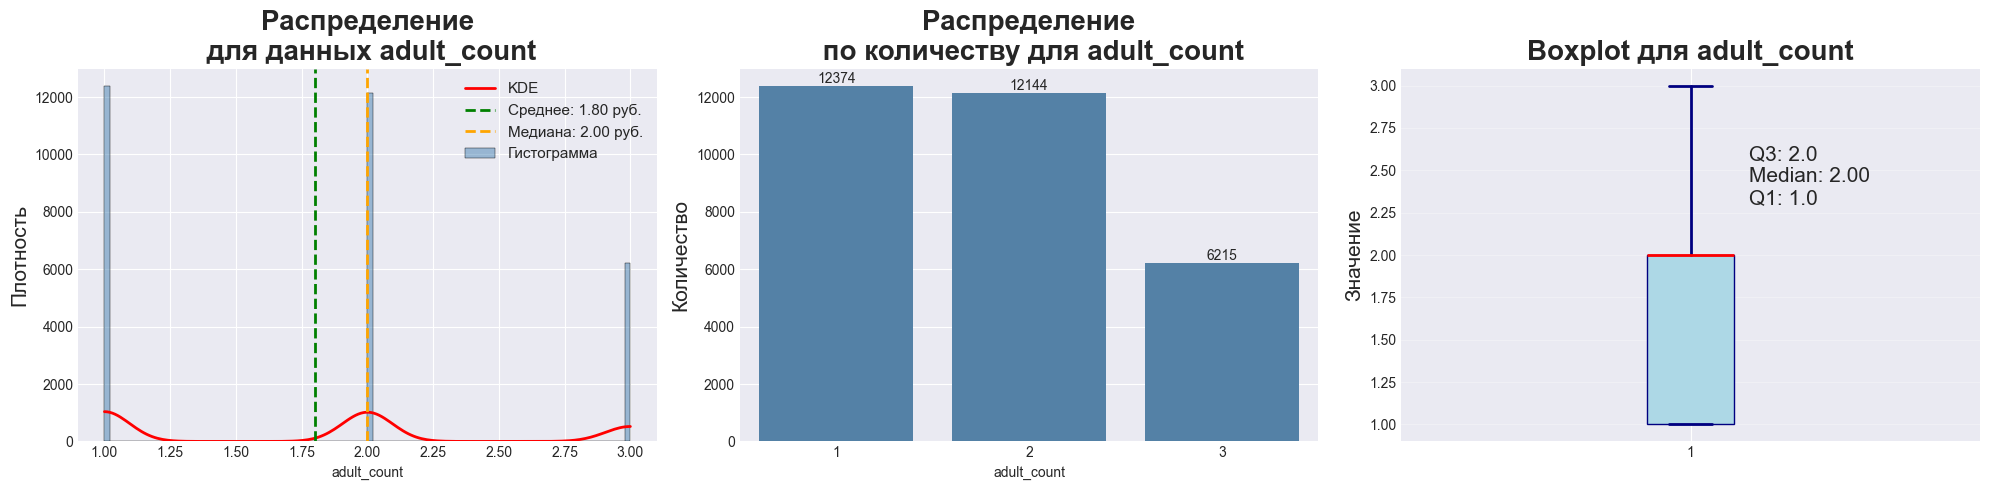

In [ ]:
# Выводим графики
_, axes = plt.subplots(1, 3, figsize=(20, 5))
print_histplot(df_bookings_drop_dupl, 'adult_count', axes[0])
print_countplot(df_bookings_drop_dupl, 'adult_count', axes[1])
print_boxplot(df_bookings_drop_dupl, 'adult_count', axes[2])

plt.tight_layout()
plt.show()

#### Анализ категориальных и булевых признаков

In [51]:
# Определяем категориальные признаки
category_cols_booking = df_bookings_drop_dupl.select_dtypes(include=['str', 'object', 'bool']).columns.to_list()
category_cols_booking.remove('booking_id')

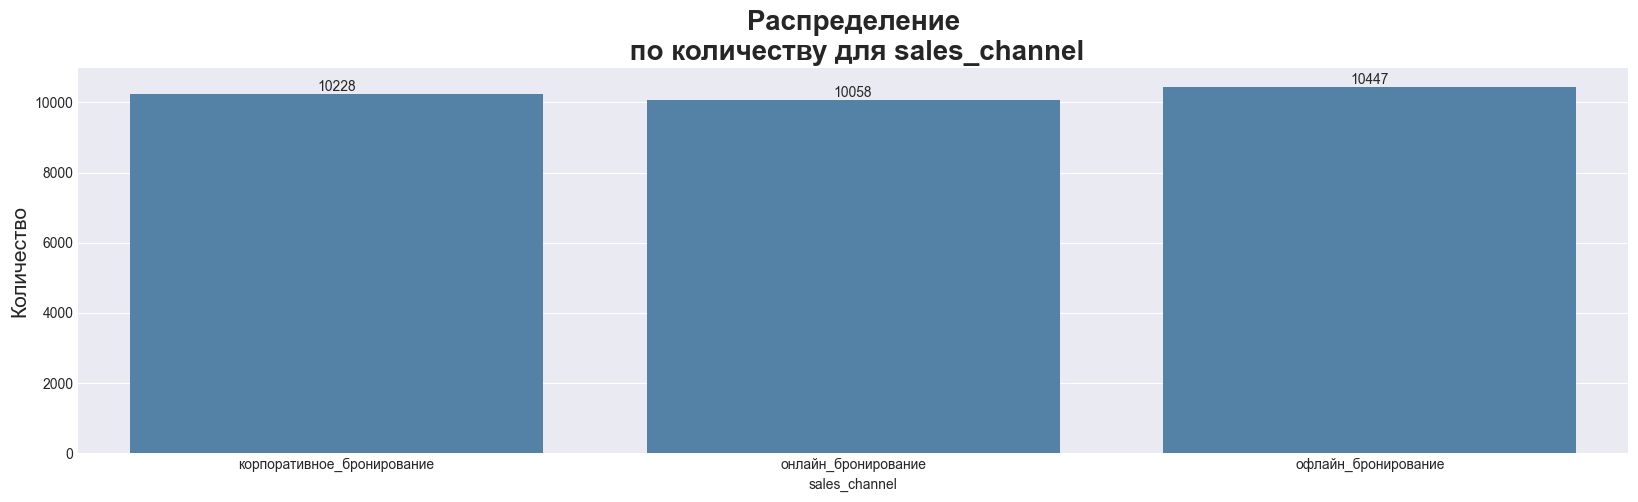

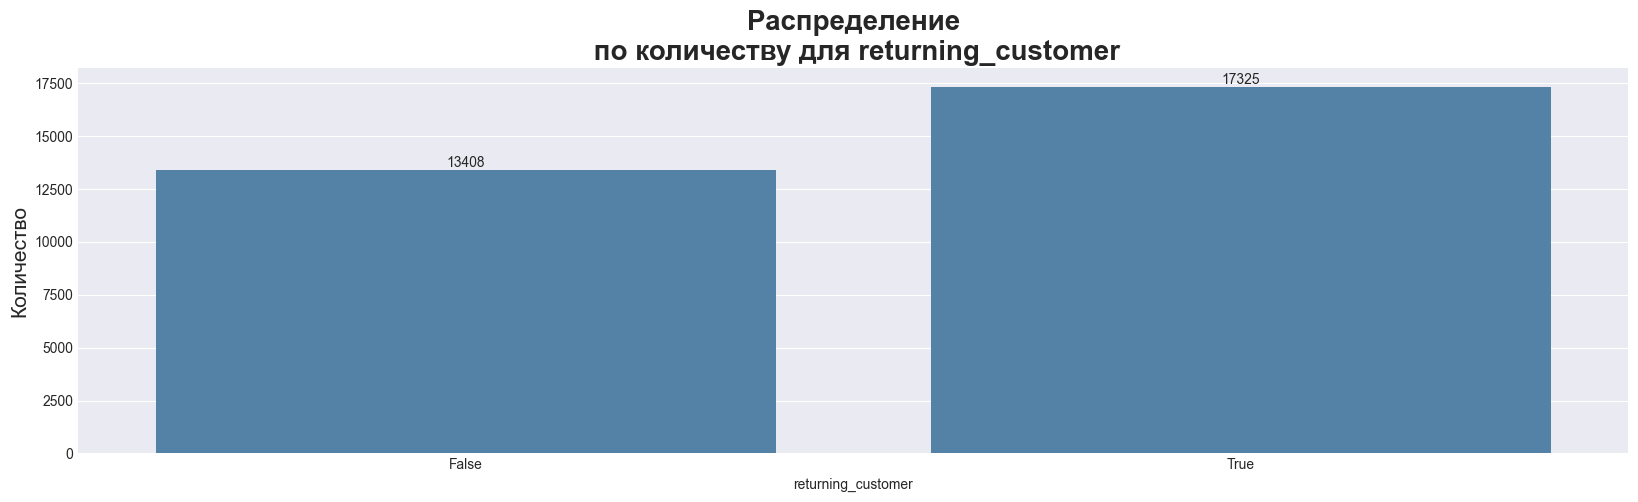

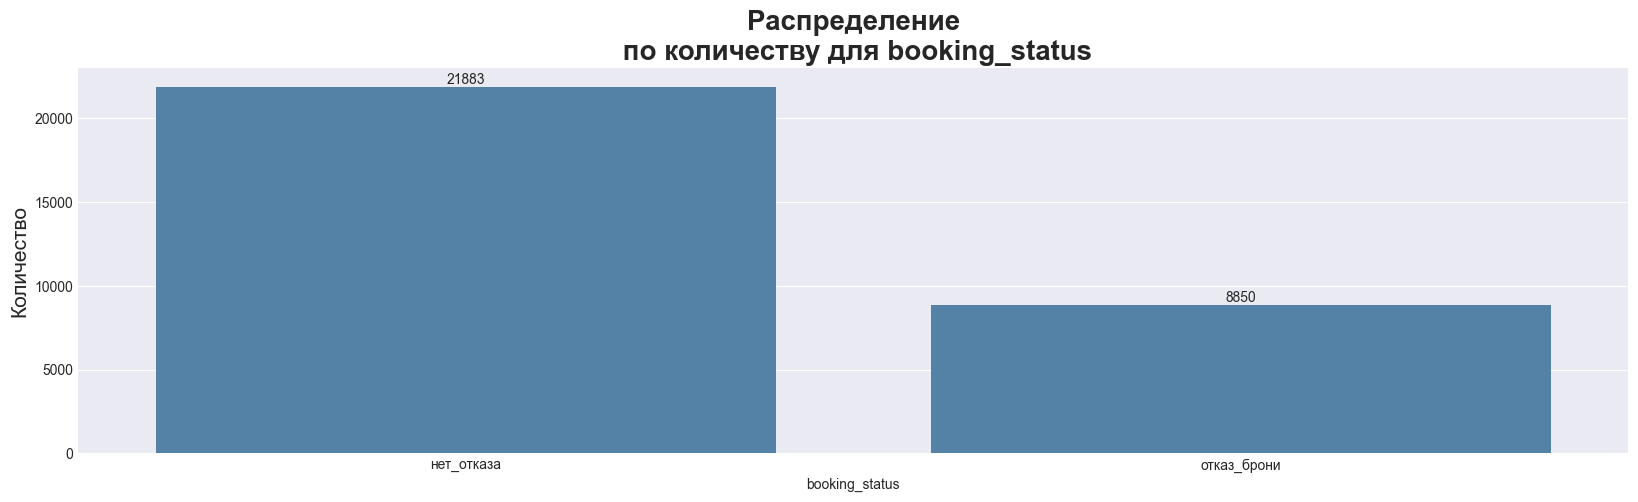

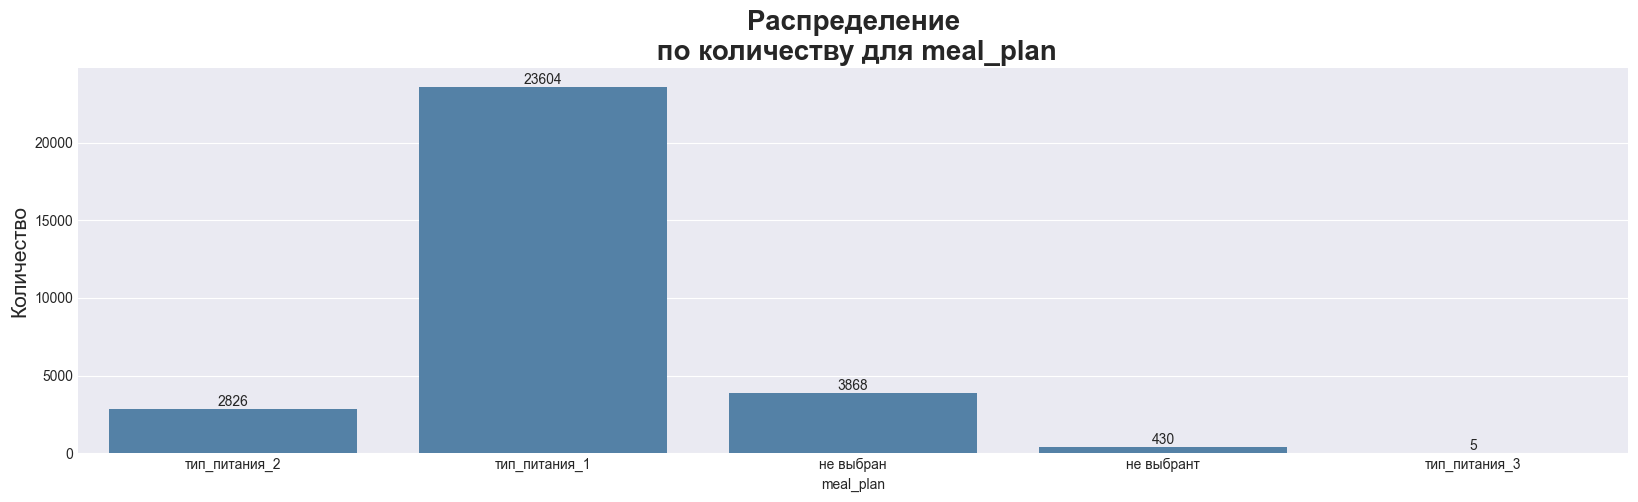

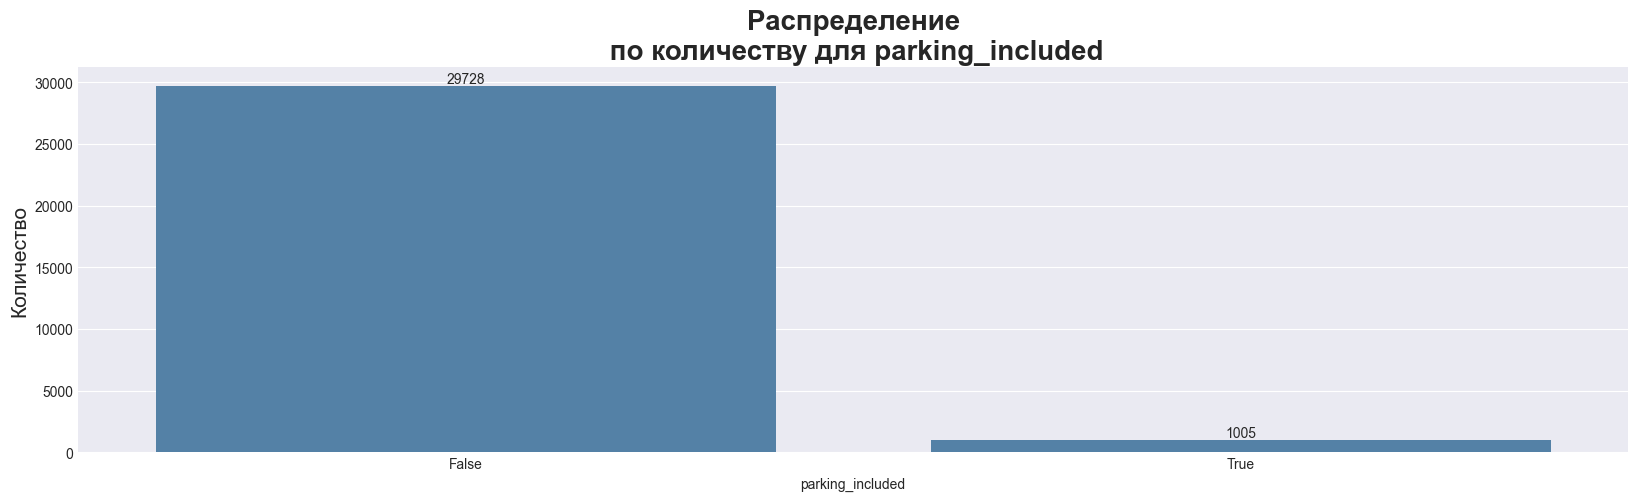

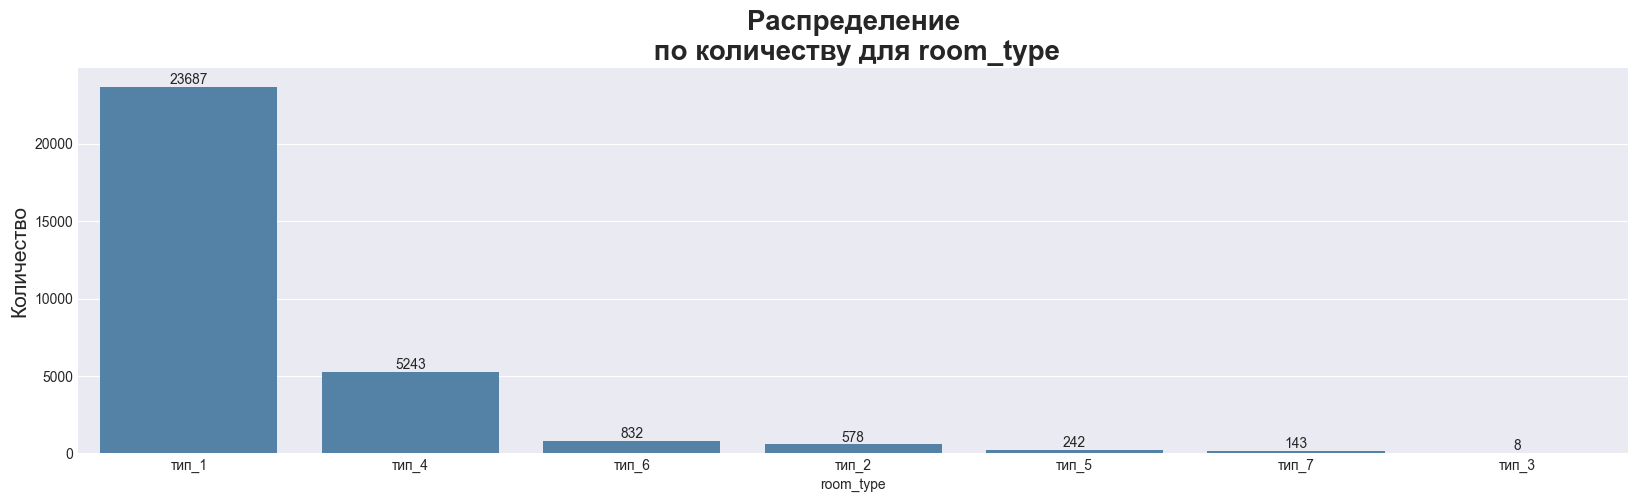

In [54]:
for col in category_cols_booking:
    _, axes = plt.subplots(1, 1, figsize=(20, 5))
    print_countplot(df_bookings_drop_dupl, col, axes)

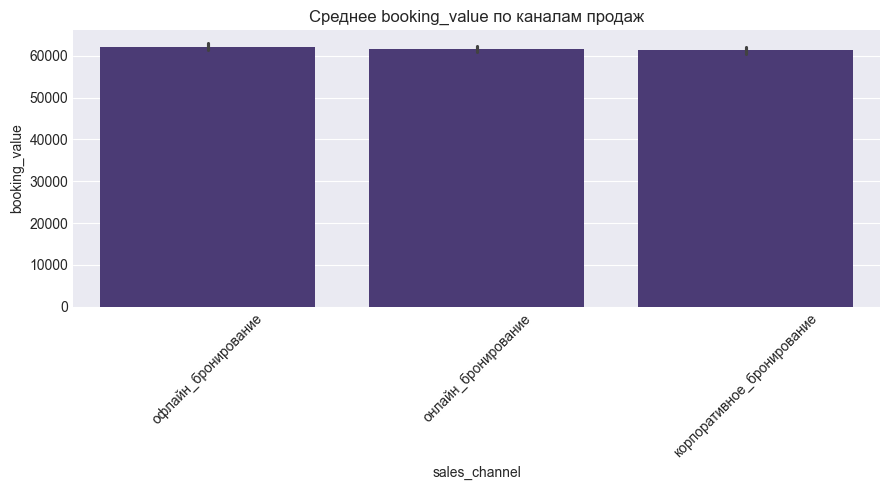

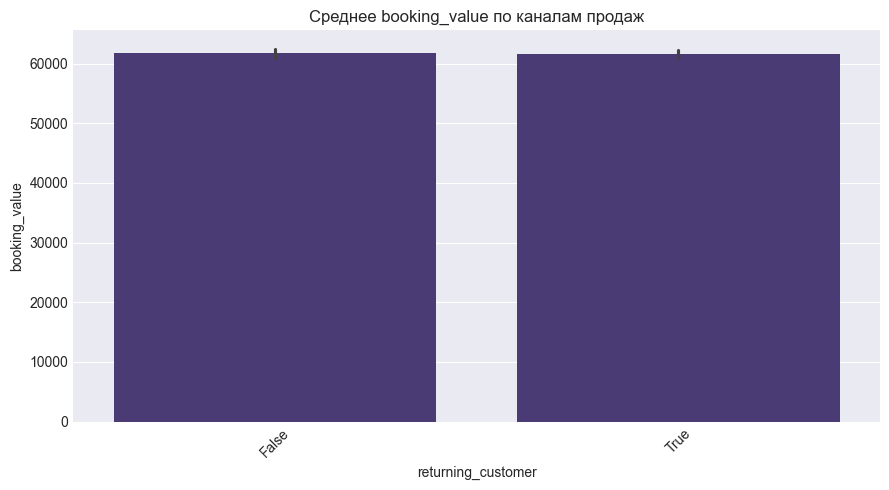

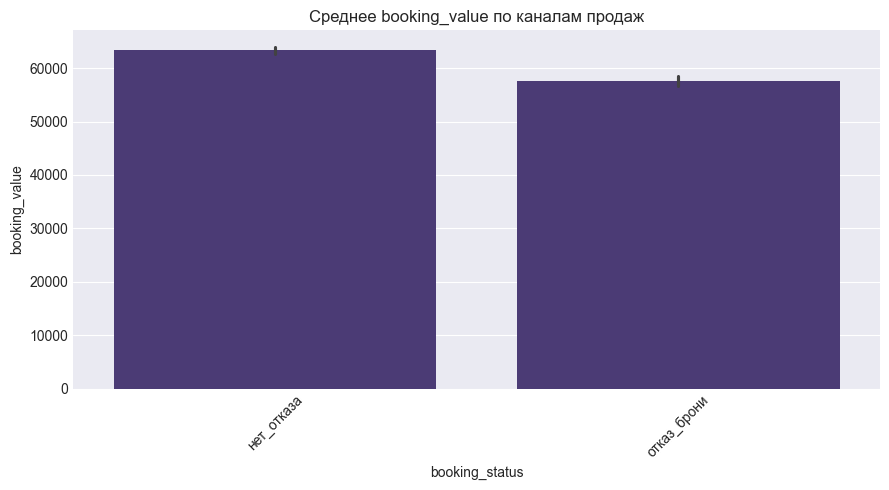

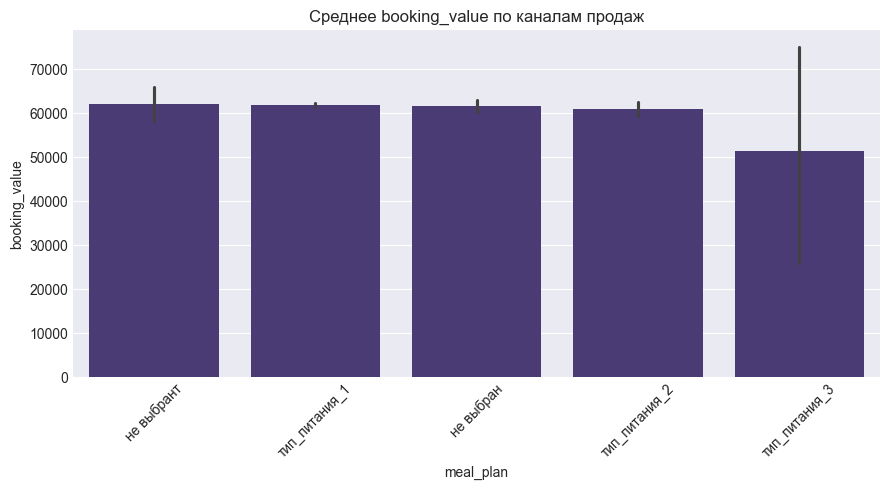

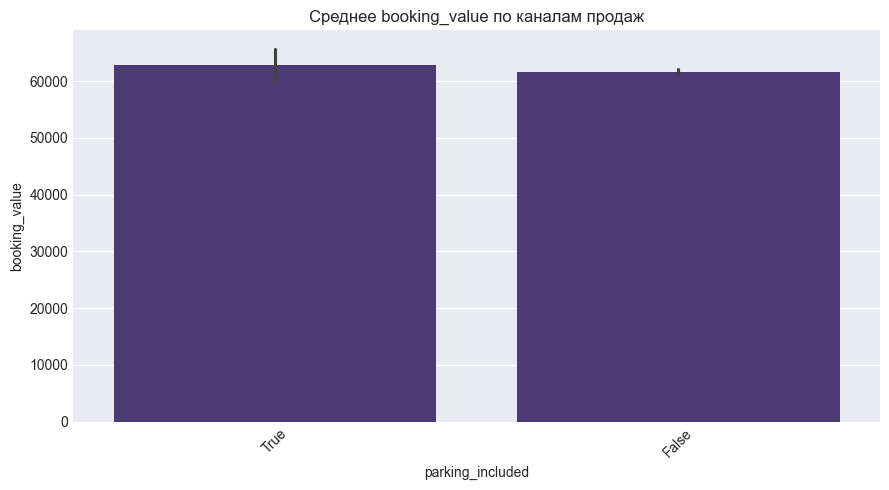

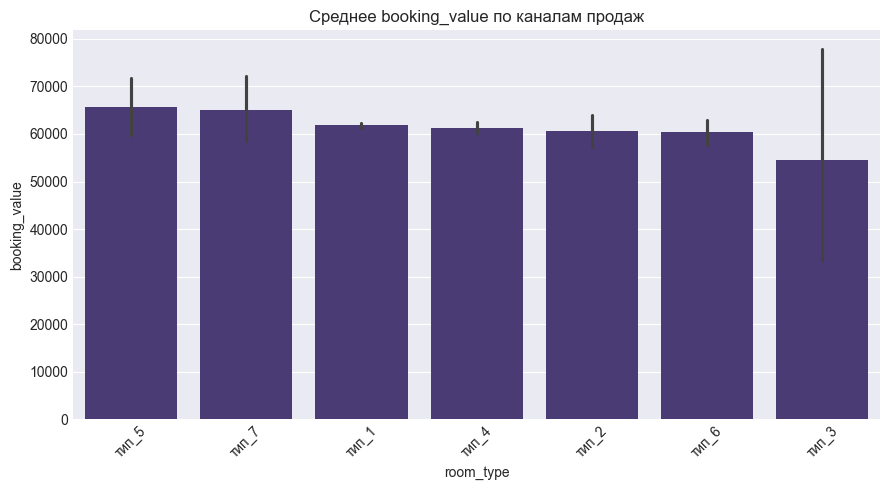

In [56]:
for col in category_cols_booking:
    plt.figure(figsize=(9, 5))
    order = (df_bookings_drop_dupl
            .groupby(col)['booking_value']
            .mean()
            .sort_values(ascending=False).index)
    sns.barplot(data=df_bookings_drop_dupl, x=col, y='booking_value', order=order)
    plt.title('Среднее booking_value по каналам продаж')
    plt.xticks(rotation=45)
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.